# Customer Analytics Project
## Project 02 — StudyBuild Community

This notebook analyzes the cleaned e-commerce customer dataset and answers six management questions:

1. Who are the main customers?
2. Which city and province are most suitable for advertising investment?
3. Which customers should be prioritized for a loyalty program?
4. Which valuable customers are at risk of becoming inactive?
5. How are discount usage, device, and payment method associated with customer behavior?
6. What should management act on first?

**Author:** Shayan Najafian

# 1. Data Loading

The cleaned dataset from Project 01 is used as the source for this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

In [2]:
DATA_FILE = "cleaned_dataset_ShayanNajafian.xlsx"

candidate_paths = [
    Path(DATA_FILE),
    Path("../data") / DATA_FILE,
    Path("../data/cleaned") / DATA_FILE,
    Path("../../dataset") / DATA_FILE,
]

FILE_PATH = next((path for path in candidate_paths if path.exists()), None)

if FILE_PATH is None:
    raise FileNotFoundError(
        f"Could not find {DATA_FILE}. Place it beside the notebook or update candidate_paths."
    )

df = pd.read_excel(FILE_PATH)
print(f"Loaded: {FILE_PATH.resolve()}")
display(df.head())

Loaded: C:\Users\Shayan Nj\OneDrive\Desktop\Codes\project-02-data-cleaning-ShayanNajafian\dataset\cleaned_dataset_ShayanNajafian.xlsx


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,"2,066.01",16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,"3,917.64",3,Card,Web,No,5,3
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,"1,248.66",22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,"6,121.45",40,Card,Android,No,4,4
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,"3,899.42",273,Online Wallet,Android,Yes,7,4


# 2. Data Validation

The dataset is checked for required columns, appropriate data types, missing values, duplicates, unique customer IDs, category consistency, and basic logical validity.

In [3]:
required_columns = [
    "customer_id", "first_name", "gender", "age", "city", "province",
    "signup_date", "membership_tier", "purchase_count", "avg_order_value",
    "total_spending", "last_purchase_days", "payment_method", "device",
    "discount_used", "returned_items", "satisfaction_score"
]

missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

# Standardize data types used throughout the analysis.
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")

numeric_columns = [
    "age", "purchase_count", "avg_order_value", "total_spending",
    "last_purchase_days", "returned_items", "satisfaction_score"
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

text_columns = [
    "first_name", "gender", "city", "province", "membership_tier",
    "payment_method", "device", "discount_used"
]
for column in text_columns:
    df[column] = df[column].astype("string").str.strip()

validation_summary = pd.Series({
    "Rows": len(df),
    "Columns": df.shape[1],
    "Duplicate rows": int(df.duplicated().sum()),
    "Missing values": int(df.isna().sum().sum()),
    "Duplicate customer IDs": int(df["customer_id"].duplicated().sum()),
    "Invalid ages": int((~df["age"].between(0, 120)).sum()),
    "Negative purchase counts": int((df["purchase_count"] < 0).sum()),
    "Negative total spending": int((df["total_spending"] < 0).sum()),
    "Negative days since last purchase": int((df["last_purchase_days"] < 0).sum()),
    "Invalid satisfaction scores": int((~df["satisfaction_score"].between(1, 5)).sum()),
    "Returned items above purchase count": int((df["returned_items"] > df["purchase_count"]).sum()),
}, name="Result")

display(validation_summary.to_frame())

,Result
Rows,60
Columns,17
Duplicate rows,0
Missing values,0
Duplicate customer IDs,0
Invalid ages,0
Negative purchase counts,0
Negative total spending,0
Negative days since last purchase,0
Invalid satisfaction scores,0


In [4]:
category_columns = [
    "gender", "membership_tier", "device", "payment_method", "discount_used"
]

category_values = {
    column: sorted(df[column].dropna().astype(str).unique().tolist())
    for column in category_columns
}

for column, values in category_values.items():
    print(f"{column}: {values}")

assert df["customer_id"].is_unique
assert df.duplicated().sum() == 0
assert df.isna().sum().sum() == 0
assert df["age"].between(0, 120).all()
assert df["satisfaction_score"].between(1, 5).all()
print("\nAll validation checks passed.")

gender: ['F', 'M']
membership_tier: ['Bronze', 'Gold', 'Silver', 'VIP']
device: ['Android', 'Web', 'iPhone']
payment_method: ['Card', 'Cash', 'Online Wallet']
discount_used: ['No', 'Yes']

All validation checks passed.


## Validation Result

The cleaned dataset contains 60 unique customers and 17 columns. No remaining missing values, duplicate rows, duplicate customer IDs, or invalid logical values were detected.

# 3. Question 1 — Who Are the Main Customers?

Customer characteristics are summarized using age groups, gender, membership tier, device, and payment method.

In [5]:
profile_df = df.dropna(
    subset=["customer_id", "gender", "age", "membership_tier", "device", "payment_method"]
).copy()

age_bins = [0, 24, 34, 44, 54, 64, np.inf]
age_labels = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65+"]
profile_df["age_group"] = pd.cut(
    profile_df["age"], bins=age_bins, labels=age_labels, include_lowest=True
)

profile_summary = pd.DataFrame({
    "Metric": [
        "Unique customers", "Average age", "Median age", "Most common gender",
        "Most common membership", "Most common device", "Most common payment method"
    ],
    "Value": [
        profile_df["customer_id"].nunique(),
        round(profile_df["age"].mean(), 2),
        round(profile_df["age"].median(), 2),
        profile_df["gender"].mode().iloc[0],
        profile_df["membership_tier"].mode().iloc[0],
        profile_df["device"].mode().iloc[0],
        profile_df["payment_method"].mode().iloc[0],
    ]
})

gender_summary = (
    profile_df["gender"].value_counts().rename_axis("gender").reset_index(name="customer_count")
)
gender_summary["percentage"] = (
    gender_summary["customer_count"] / gender_summary["customer_count"].sum() * 100
).round(1)

display(profile_summary)
display(gender_summary)

,Metric,Value
0,Unique customers,60
1,Average age,43.70
2,Median age,45.00
3,Most common gender,M
4,Most common membership,Gold
5,Most common device,Android
6,Most common payment method,Online Wallet


,gender,customer_count,percentage
0,M,35,58.30
1,F,25,41.70


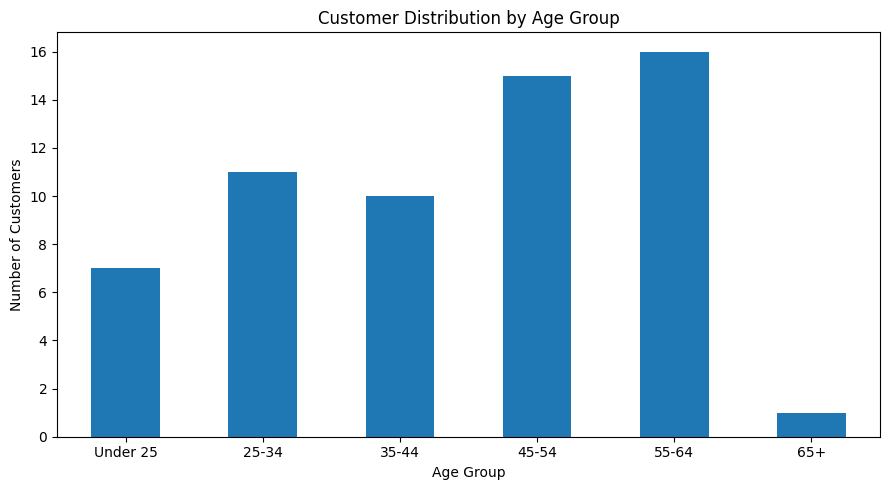

In [6]:
age_counts = profile_df["age_group"].value_counts(sort=False)
age_counts.plot(kind="bar", figsize=(9, 5))
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

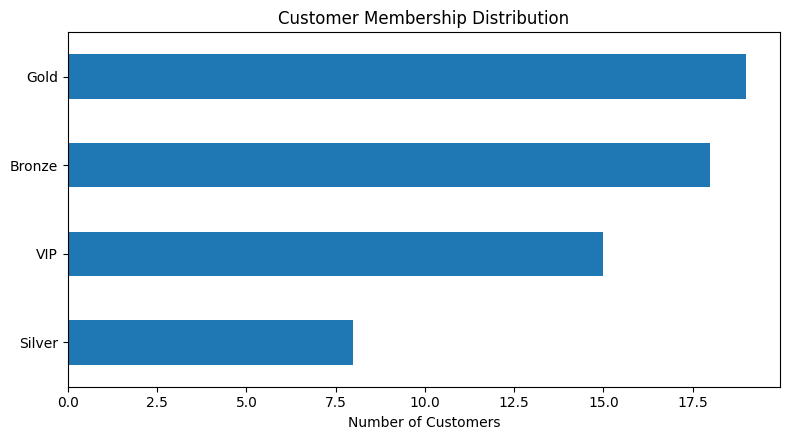

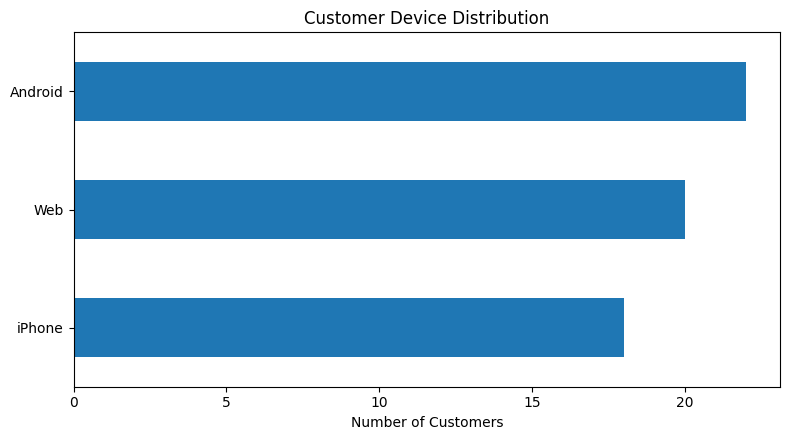

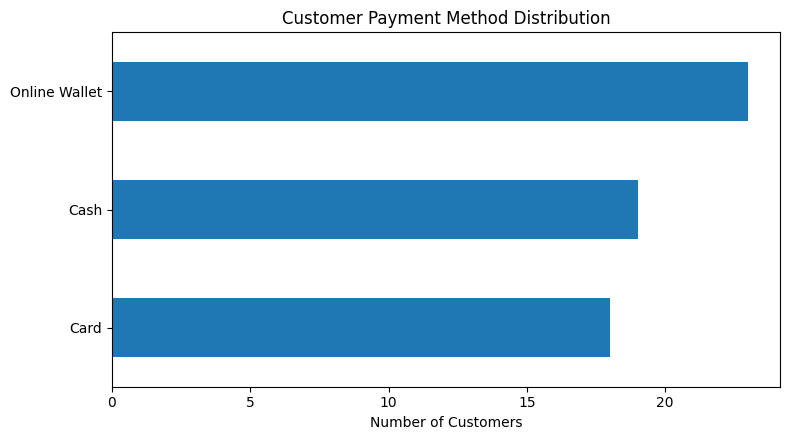

In [7]:
for column, title in [
    ("membership_tier", "Customer Membership Distribution"),
    ("device", "Customer Device Distribution"),
    ("payment_method", "Customer Payment Method Distribution"),
]:
    counts = profile_df[column].value_counts().sort_values()
    counts.plot(kind="barh", figsize=(8, 4.5))
    plt.title(title)
    plt.xlabel("Number of Customers")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

## Customer Profile Findings

- The average customer age is **43.7**, and the two largest age groups are **45–54** and **55–64**.
- Male customers represent **58.3%** of customers and female customers **41.7%**.
- **Gold** is the largest membership tier.
- **Android** is the most common device, and **Online Wallet** is the most common payment method.

**Recommendation:** Prioritize mobile-friendly campaigns for middle-aged customers while continuing to evaluate whether smaller groups create higher financial value.

# 4. Question 2 — Which City and Province Are Best for Advertising?

Locations are compared using customer count, total revenue, average customer spending, purchase activity, order value, and satisfaction. Locations with fewer than three customers are excluded from the main comparison to reduce instability from very small samples.

In [8]:
location_df = df.dropna(
    subset=[
        "province", "city", "customer_id", "total_spending",
        "purchase_count", "avg_order_value", "satisfaction_score"
    ]
).copy()

city_summary = (
    location_df.groupby(["province", "city"], as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_spending", "sum"),
        avg_customer_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_satisfaction=("satisfaction_score", "mean"),
    )
)

city_summary = city_summary[city_summary["customer_count"] >= 3].copy()
city_summary = city_summary.sort_values("total_revenue", ascending=False)

display(city_summary.round(2))

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
5,Khorasan,Mashhad,11,"64,118.44","5,828.95",22.64,210.51,2.91
1,East Azerbaijan,Tabriz,12,"36,192.49","3,016.04",15.75,238.90,3.00
0,Alborz,Karaj,7,"26,189.81","3,741.40",16.00,211.44,2.86
6,Khuzestan,Ahvaz,8,"23,384.78","2,923.10",13.88,216.53,3.50
4,Isfahan,Isfahan,5,"21,975.32","4,395.06",19.80,212.68,4.40
2,Fars,Shiraz,6,"20,715.92","3,452.65",16.33,180.98,2.00
3,Gilan,Rasht,5,"15,168.54","3,033.71",16.40,241.55,2.60
7,Tehran,Tehran,6,"15,161.29","2,526.88",17.17,172.93,2.67


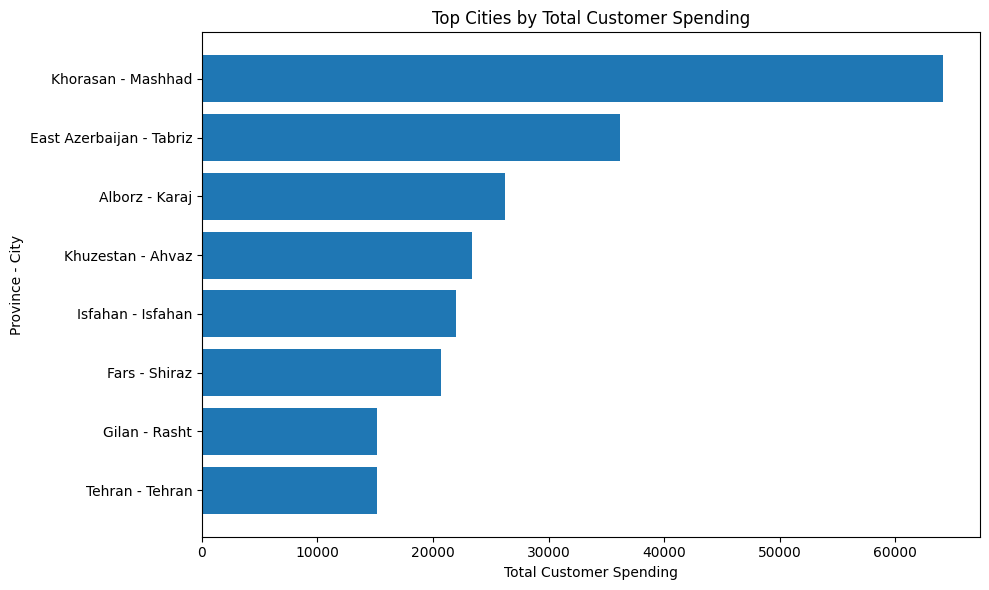

In [9]:
top_cities = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")
labels = top_cities["province"] + " - " + top_cities["city"]

plt.figure(figsize=(10, 6))
plt.barh(labels, top_cities["total_revenue"])
plt.title("Top Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")
plt.ylabel("Province - City")
plt.tight_layout()
plt.show()

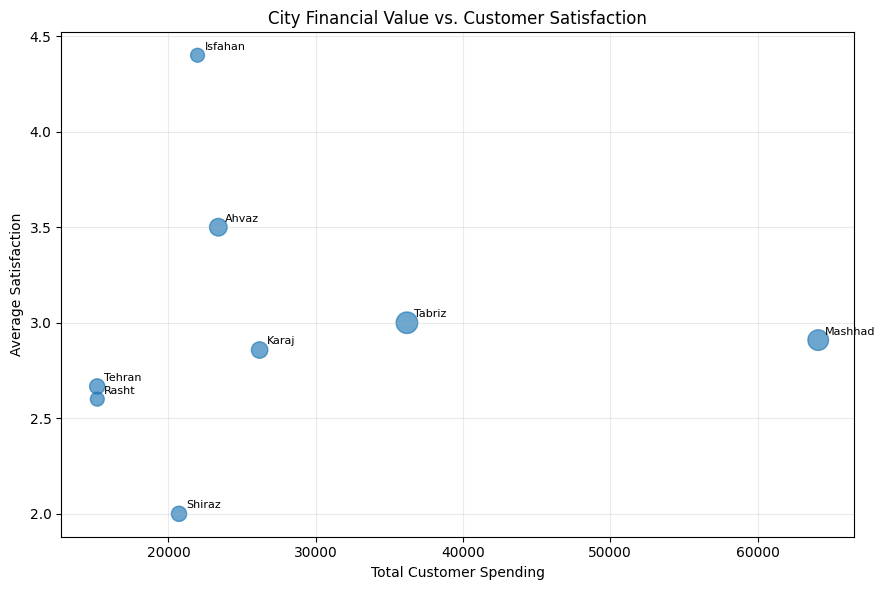

In [10]:
plt.figure(figsize=(9, 6))
plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 20,
    alpha=0.65,
)

for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

plt.title("City Financial Value vs. Customer Satisfaction")
plt.xlabel("Total Customer Spending")
plt.ylabel("Average Satisfaction")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [11]:
recommended_locations = city_summary.sort_values(
    ["total_revenue", "avg_satisfaction", "customer_count"],
    ascending=[False, False, False]
).head(2).copy()

recommended_locations.insert(0, "role", ["Primary recommendation", "Alternative"])
recommended_locations["advantage"] = recommended_locations.apply(
    lambda row: (
        f"{int(row['customer_count'])} customers; revenue {row['total_revenue']:,.2f}; "
        f"average customer spending {row['avg_customer_spending']:,.2f}."
    ),
    axis=1,
)

overall_satisfaction = df["satisfaction_score"].mean()
recommended_locations["risk"] = recommended_locations.apply(
    lambda row: (
        "Satisfaction is below the overall average and should be improved before scaling."
        if row["avg_satisfaction"] < overall_satisfaction
        else "The sample is limited, so performance should be monitored as the campaign scales."
    ),
    axis=1,
)

display(recommended_locations[[
    "role", "province", "city", "customer_count", "total_revenue",
    "avg_customer_spending", "avg_satisfaction", "advantage", "risk"
]].round(2))

,role,province,city,customer_count,total_revenue,avg_customer_spending,avg_satisfaction,advantage,risk
5,Primary recommendation,Khorasan,Mashhad,11,"64,118.44","5,828.95",2.91,"11 customers; revenue 64,118.44; average custo...",Satisfaction is below the overall average and ...
1,Alternative,East Azerbaijan,Tabriz,12,"36,192.49","3,016.04",3.00,"12 customers; revenue 36,192.49; average custo...","The sample is limited, so performance should b..."


## Geographic Findings

- **Mashhad, Khorasan** is the primary recommendation because it generates the highest total revenue and the highest average customer spending.
- **Tabriz, East Azerbaijan** is the alternative because it has the largest customer base and the second-highest revenue.
- Mashhad's satisfaction is slightly below the overall average, so additional advertising should be paired with customer-experience improvement.
- Isfahan has the highest satisfaction and strong average spending, but its smaller sample makes the estimate less stable.

# 5. Question 3 — Which Customers Should Join the Loyalty Program?

A loyalty score combines financial value, purchase frequency, recency, and satisfaction. All metrics are normalized to a 0–1 range before weighting.

**Analytical weight assumptions:**

- Total spending: 35%
- Purchase frequency: 30%
- Recent activity: 20%
- Satisfaction: 15%

In [12]:
loyalty_df = df.dropna(
    subset=[
        "customer_id", "first_name", "membership_tier", "purchase_count",
        "total_spending", "last_purchase_days", "satisfaction_score"
    ]
).copy()

def min_max_score(series):
    minimum = series.min()
    maximum = series.max()
    if maximum == minimum:
        return pd.Series(1.0, index=series.index)
    return (series - minimum) / (maximum - minimum)

for column in ["purchase_count", "total_spending", "satisfaction_score"]:
    loyalty_df[f"{column}_score"] = min_max_score(loyalty_df[column])

loyalty_df["recency_score"] = 1 - min_max_score(loyalty_df["last_purchase_days"])

weights = {
    "total_spending_score": 0.35,
    "purchase_count_score": 0.30,
    "recency_score": 0.20,
    "satisfaction_score_score": 0.15,
}

loyalty_df["loyalty_score"] = sum(
    loyalty_df[column] * weight for column, weight in weights.items()
)

# Identify the largest weighted contribution for a concise selection reason.
loyalty_df["financial_contribution"] = loyalty_df["total_spending_score"] * 0.35
loyalty_df["frequency_contribution"] = loyalty_df["purchase_count_score"] * 0.30
loyalty_df["recency_contribution"] = loyalty_df["recency_score"] * 0.20
loyalty_df["satisfaction_contribution"] = loyalty_df["satisfaction_score_score"] * 0.15

reason_map = {
    "financial_contribution": "High financial value",
    "frequency_contribution": "High purchase frequency",
    "recency_contribution": "Recent activity",
    "satisfaction_contribution": "High satisfaction",
}
contribution_columns = list(reason_map)
loyalty_df["selection_reason"] = (
    loyalty_df[contribution_columns].idxmax(axis=1).map(reason_map)
)

top_loyal_customers = loyalty_df.nlargest(10, "loyalty_score")[[
    "customer_id", "first_name", "membership_tier", "purchase_count",
    "total_spending", "last_purchase_days", "satisfaction_score",
    "loyalty_score", "selection_reason"
]].copy()

display(top_loyal_customers.round(3))

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score,selection_reason
56,1057,Maryam,Bronze,31,"13,532.74",82,4,0.72,High purchase frequency
29,1030,Sina,VIP,26,"25,000.00",340,4,0.70,High financial value
43,1044,Mina,Gold,33,"14,354.34",165,2,0.63,High purchase frequency
58,1059,Ali,Gold,31,"8,898.55",224,5,0.62,High purchase frequency
3,1004,Sina,Gold,23,"6,121.45",40,4,0.57,High purchase frequency
13,1014,Reza,VIP,31,"3,353.89",97,4,0.57,High purchase frequency
32,1033,Neda,VIP,24,"5,521.20",112,5,0.57,High purchase frequency
8,1009,Kimia,Silver,34,"11,615.42",232,2,0.56,High purchase frequency
16,1017,Parsa,VIP,30,"3,239.40",135,4,0.54,High purchase frequency
22,1023,Ali,Bronze,31,"3,851.44",170,4,0.54,High purchase frequency


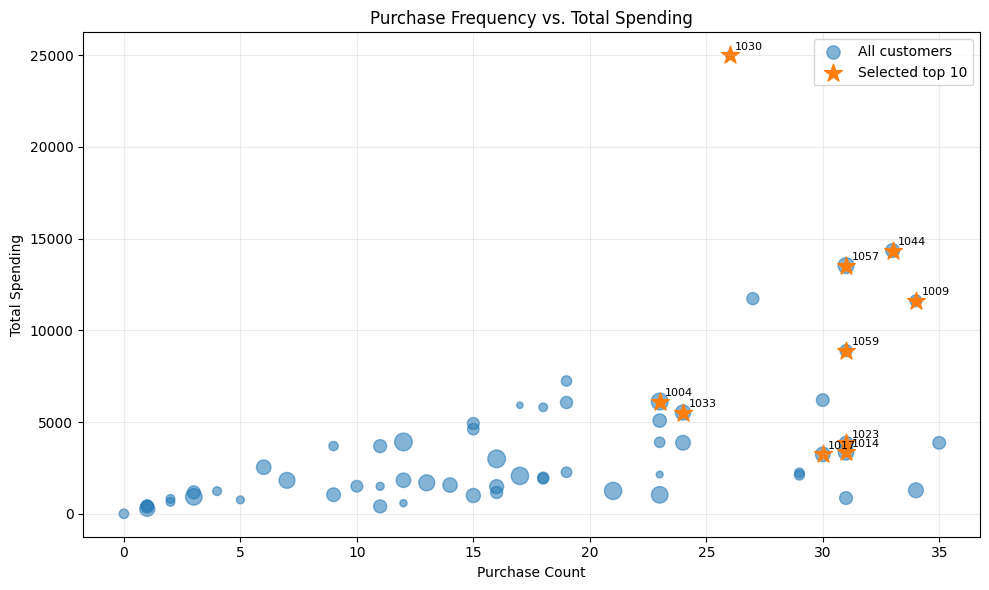

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(
    loyalty_df["purchase_count"],
    loyalty_df["total_spending"],
    s=(loyalty_df["recency_score"] + 0.15) * 140,
    alpha=0.55,
    label="All customers",
)
plt.scatter(
    top_loyal_customers["purchase_count"],
    top_loyal_customers["total_spending"],
    s=180,
    marker="*",
    label="Selected top 10",
)

for _, row in top_loyal_customers.iterrows():
    plt.annotate(
        str(row["customer_id"]),
        (row["purchase_count"], row["total_spending"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

plt.title("Purchase Frequency vs. Total Spending")
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Loyalty Findings

- The selected customers combine financial value, repeat purchasing, recency, and satisfaction rather than being chosen only by membership tier.
- Maryam (customer 1057) ranks highly despite Bronze membership, showing that the current membership label does not fully represent behavioral value.
- Sina (customer 1030) has exceptional historical value but very low recency, so the customer belongs in both loyalty and retention discussions.

**Recommendation:** Use the top-ten table for personalized loyalty benefits, but review customers with long inactivity before issuing standard rewards.

# 6. Question 4 — Which Valuable Customers Are at Risk?

A customer is classified as valuable and at risk only when all three conditions are true:

- Total spending is at or above the 75th percentile.
- Purchase count is at or above the median.
- Days since last purchase is at or above the 75th percentile.

In [14]:
risk_df = df.dropna(
    subset=[
        "customer_id", "first_name", "membership_tier", "total_spending",
        "purchase_count", "last_purchase_days", "satisfaction_score"
    ]
).copy()

spending_threshold = risk_df["total_spending"].quantile(0.75)
purchase_threshold = risk_df["purchase_count"].median()
inactivity_threshold = risk_df["last_purchase_days"].quantile(0.75)

risk_df["at_risk"] = (
    (risk_df["total_spending"] >= spending_threshold)
    & (risk_df["purchase_count"] >= purchase_threshold)
    & (risk_df["last_purchase_days"] >= inactivity_threshold)
)

at_risk_customers = risk_df.loc[risk_df["at_risk"], [
    "customer_id", "first_name", "membership_tier", "purchase_count",
    "total_spending", "last_purchase_days", "satisfaction_score"
]].sort_values(["total_spending", "last_purchase_days"], ascending=[False, False])

at_risk_customers["recommended_action"] = np.where(
    at_risk_customers["satisfaction_score"] <= 2,
    "Service recovery plus a personalized reactivation offer",
    "Personalized reactivation offer and direct follow-up",
)

threshold_table = pd.DataFrame({
    "Threshold": ["Spending (75th percentile)", "Purchase count (median)", "Inactivity (75th percentile)"],
    "Value": [spending_threshold, purchase_threshold, inactivity_threshold],
})

display(threshold_table.round(2))
print(f"At-risk valuable customers: {len(at_risk_customers)}")
display(at_risk_customers.round(2))

,Threshold,Value
0,Spending (75th percentile),"4,692.15"
1,Purchase count (median),17.00
2,Inactivity (75th percentile),273.75


At-risk valuable customers: 4


,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,recommended_action
29,1030,Sina,VIP,26,"25,000.00",340,4,Personalized reactivation offer and direct fol...
9,1010,Arash,Silver,19,"7,241.47",276,1,Service recovery plus a personalized reactivat...
34,1035,Arash,Bronze,17,"5,918.21",365,3,Personalized reactivation offer and direct fol...
52,1053,Sina,Gold,18,"5,805.54",320,1,Service recovery plus a personalized reactivat...


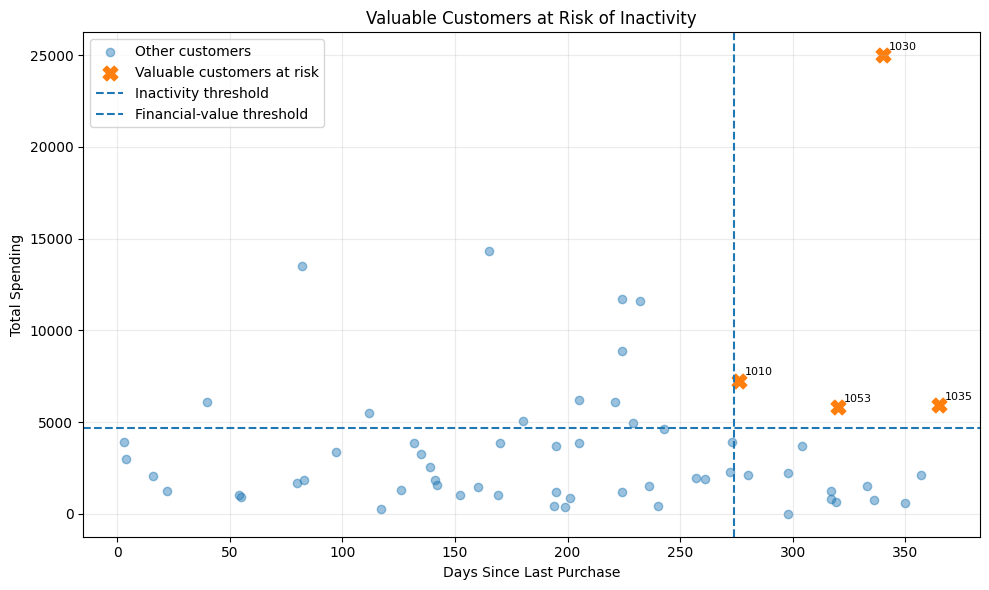

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.45,
    label="Other customers",
)
plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X",
    s=110,
    label="Valuable customers at risk",
)
plt.axvline(inactivity_threshold, linestyle="--", label="Inactivity threshold")
plt.axhline(spending_threshold, linestyle="--", label="Financial-value threshold")

for _, row in risk_df.loc[risk_df["at_risk"]].iterrows():
    plt.annotate(
        str(row["customer_id"]),
        (row["last_purchase_days"], row["total_spending"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

plt.title("Valuable Customers at Risk of Inactivity")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## At-Risk Findings

- Four customers meet all three value, frequency, and inactivity conditions.
- Customer **1030 (Sina)** is the highest-priority case because of very high historical spending and 340 days since the last purchase.
- Customers with low satisfaction require service recovery, while satisfied but inactive customers should receive a personalized return offer.

This analysis identifies **risk signals**, not confirmed churn, because the dataset does not contain a complete order history.

# 7. Question 5 — How Are Discount, Device, and Payment Method Associated with Behavior?

This section is descriptive. It compares observed spending, purchase frequency, average order value, returned items, and satisfaction. It does **not** prove cause and effect.

In [16]:
factor_df = df.dropna(
    subset=[
        "discount_used", "device", "payment_method", "total_spending",
        "purchase_count", "avg_order_value", "returned_items", "satisfaction_score"
    ]
).copy()

summary_by_discount = (
    factor_df.groupby("discount_used", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        avg_total_spending=("total_spending", "mean"),
        avg_purchase_count=("purchase_count", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_returned_items=("returned_items", "mean"),
        avg_satisfaction=("satisfaction_score", "mean"),
    )
)

display(summary_by_discount.round(2))

,discount_used,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,No,34,"3,736.74",17.29,220.70,4.26,2.76
1,Yes,26,"3,686.82",17.50,203.29,4.08,3.27


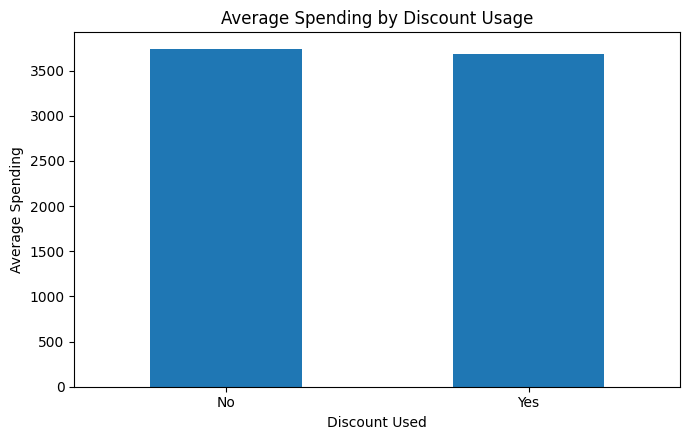

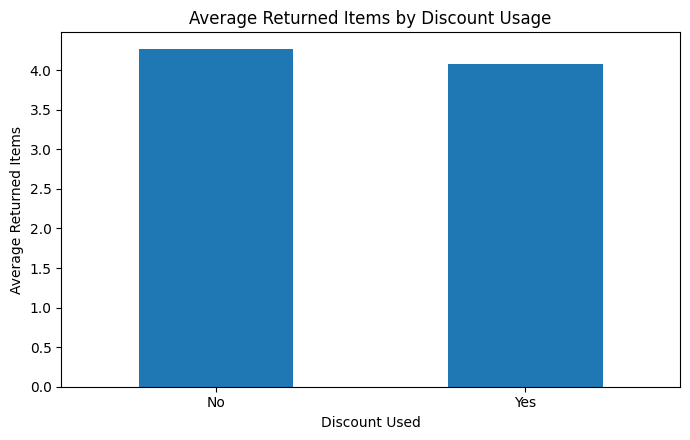

In [17]:
for metric, title, ylabel in [
    ("avg_total_spending", "Average Spending by Discount Usage", "Average Spending"),
    ("avg_returned_items", "Average Returned Items by Discount Usage", "Average Returned Items"),
]:
    summary_by_discount.plot(
        x="discount_used", y=metric, kind="bar", legend=False, figsize=(7, 4.5)
    )
    plt.title(title)
    plt.xlabel("Discount Used")
    plt.ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [18]:
device_summary = (
    factor_df.groupby("device")["total_spending"]
    .agg(["count", "mean"])
    .query("count >= 3")
    .sort_values("mean", ascending=False)
)
payment_summary = (
    factor_df.groupby("payment_method")["total_spending"]
    .agg(["count", "mean"])
    .query("count >= 3")
    .sort_values("mean", ascending=False)
)

device_summary.columns = ["customer_count", "avg_total_spending"]
payment_summary.columns = ["customer_count", "avg_total_spending"]

display(device_summary.round(2))
display(payment_summary.round(2))

,customer_count,avg_total_spending
device,,
Web,20,"3,943.80"
iPhone,18,"3,773.94"
Android,22,"3,459.07"


,customer_count,avg_total_spending
payment_method,,
Cash,19,"4,251.68"
Card,18,"3,929.00"
Online Wallet,23,"3,104.46"


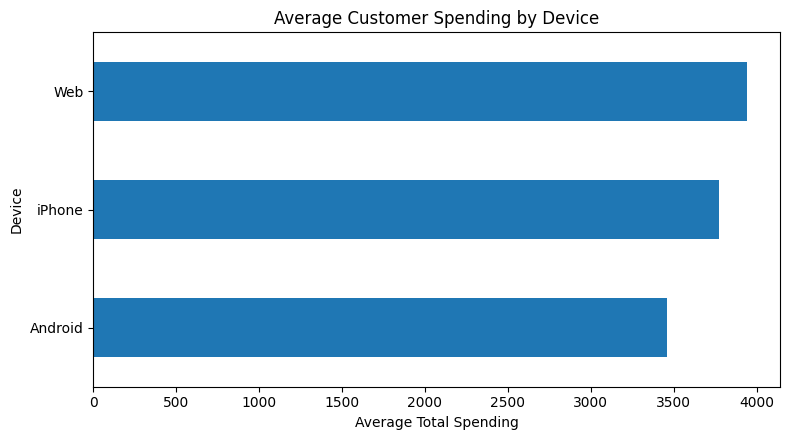

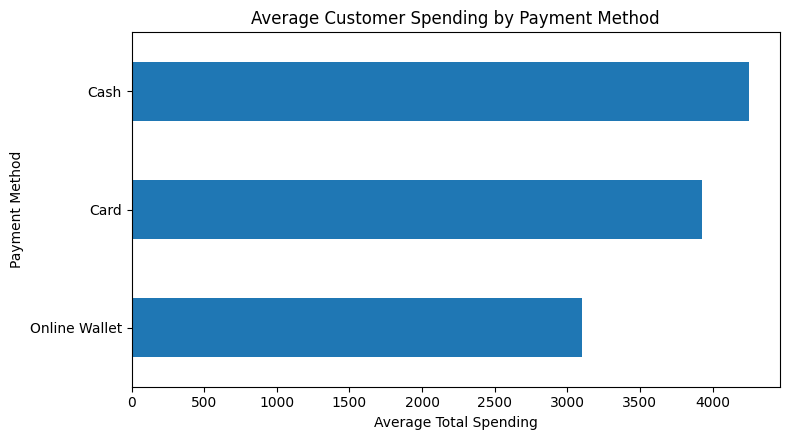

In [19]:
for summary, title, label in [
    (device_summary, "Average Customer Spending by Device", "Device"),
    (payment_summary, "Average Customer Spending by Payment Method", "Payment Method"),
]:
    summary.sort_values("avg_total_spending")["avg_total_spending"].plot(
        kind="barh", figsize=(8, 4.5)
    )
    plt.title(title)
    plt.xlabel("Average Total Spending")
    plt.ylabel(label)
    plt.tight_layout()
    plt.show()

## Factor Findings

- Discount users and non-users have nearly identical average total spending and purchase counts.
- Discount users show higher observed average satisfaction, while their average returned-item count is slightly lower.
- Web customers have the highest average spending among devices.
- Cash users have the highest average spending among payment methods.

**This analysis describes observed relationships and does not prove that discounts caused changes in customer behavior.**

**Recommendation:** Use targeted discounts for retention experiments rather than blanket promotions, and measure the result with a controlled test where possible.

# 8. Question 6 — Five-Minute Management Report

The management summary uses no more than six KPIs, three selected charts, and three recommendations structured as **KPI → Evidence → Action**.

In [20]:
kpi_summary = pd.Series({
    "Unique customers": df["customer_id"].nunique(),
    "Total customer spending": df["total_spending"].sum(),
    "Average spending per customer": df["total_spending"].mean(),
    "Average purchase count": df["purchase_count"].mean(),
    "Average satisfaction": df["satisfaction_score"].mean(),
    "Total returned items": df["returned_items"].sum(),
}, name="Value")

display(kpi_summary.to_frame().round(2))

,Value
Unique customers,60.00
Total customer spending,"222,906.59"
Average spending per customer,"3,715.11"
Average purchase count,17.38
Average satisfaction,2.98
Total returned items,251.00


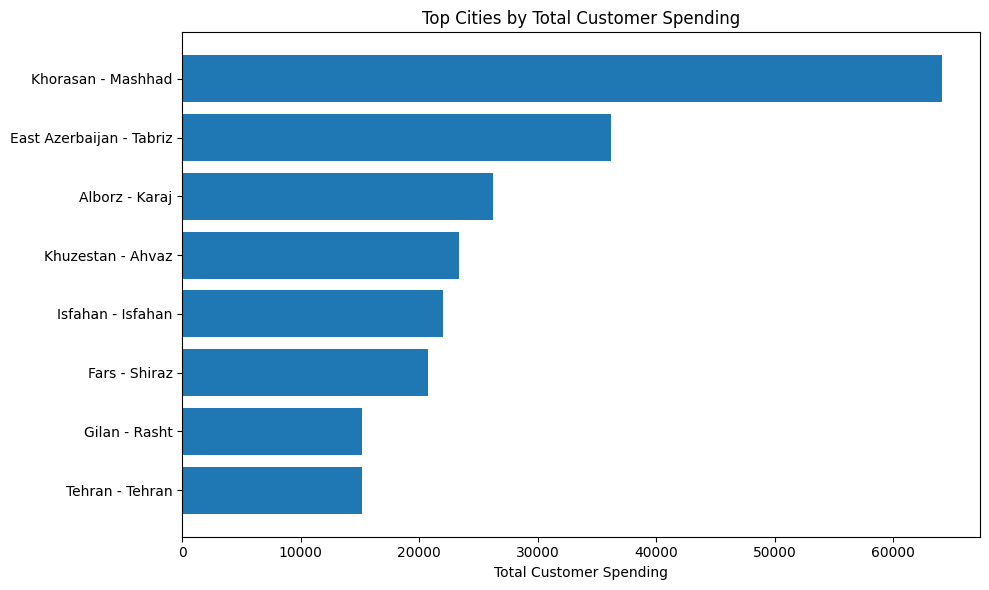

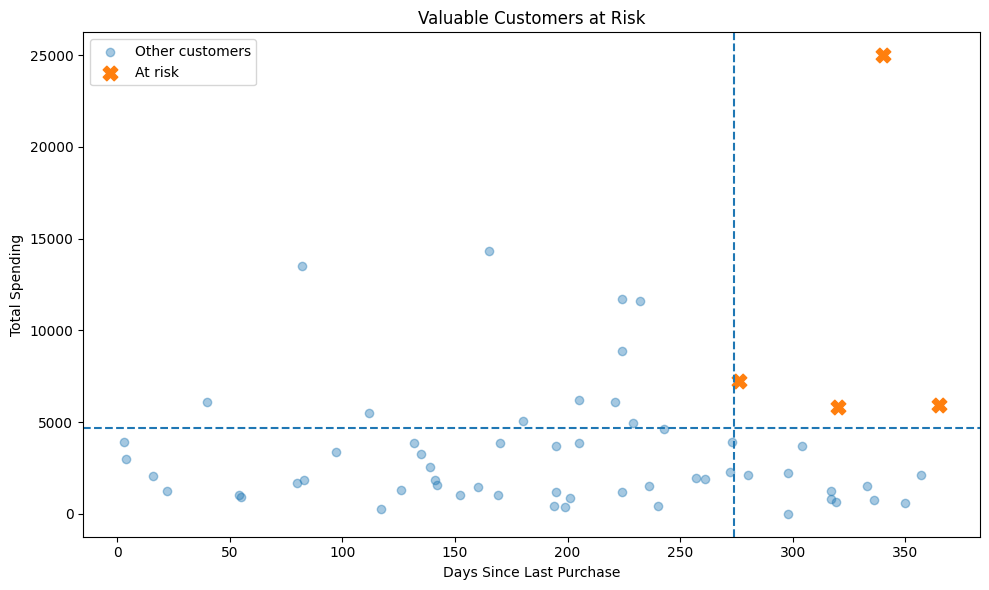

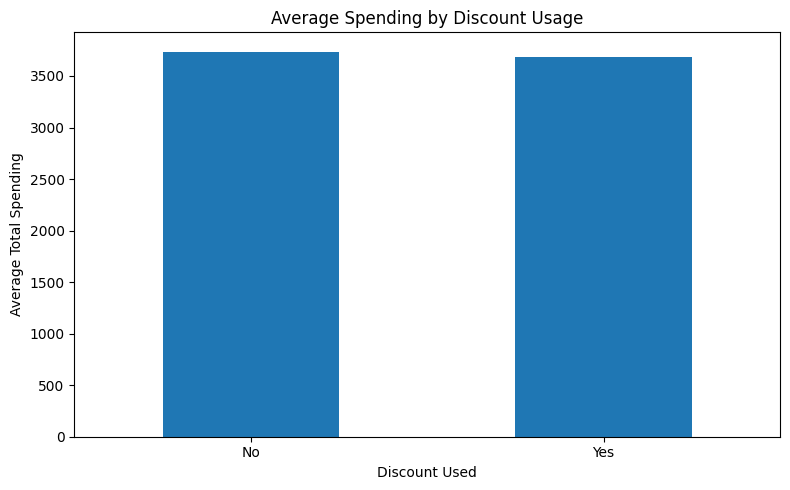

In [21]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Management chart 1: geographic opportunity
chart1 = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")
chart1_labels = chart1["province"] + " - " + chart1["city"]
plt.figure(figsize=(10, 6))
plt.barh(chart1_labels, chart1["total_revenue"])
plt.title("Top Cities by Total Customer Spending")
plt.xlabel("Total Customer Spending")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_top_cities.png", dpi=160, bbox_inches="tight")
plt.show()

# Management chart 2: retention risk
plt.figure(figsize=(10, 6))
plt.scatter(
    risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[~risk_df["at_risk"], "total_spending"],
    alpha=0.4,
    label="Other customers",
)
plt.scatter(
    risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
    risk_df.loc[risk_df["at_risk"], "total_spending"],
    marker="X", s=110, label="At risk",
)
plt.axvline(inactivity_threshold, linestyle="--")
plt.axhline(spending_threshold, linestyle="--")
plt.title("Valuable Customers at Risk")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_at_risk_customers.png", dpi=160, bbox_inches="tight")
plt.show()

# Management chart 3: discount comparison
summary_by_discount.plot(
    x="discount_used", y="avg_total_spending", kind="bar", legend=False, figsize=(8, 5)
)
plt.title("Average Spending by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_discount_spending.png", dpi=160, bbox_inches="tight")
plt.show()

In [22]:
primary_location = recommended_locations.iloc[0]
primary_risk_customer = at_risk_customers.iloc[0]
no_discount = summary_by_discount.loc[summary_by_discount["discount_used"] == "No"].iloc[0]
yes_discount = summary_by_discount.loc[summary_by_discount["discount_used"] == "Yes"].iloc[0]

management_actions = pd.DataFrame([
    {
        "KPI": "Top city revenue",
        "Evidence": (
            f"{primary_location['city']} generated {primary_location['total_revenue']:,.2f} "
            f"from {int(primary_location['customer_count'])} customers; average satisfaction "
            f"was {primary_location['avg_satisfaction']:.2f}."
        ),
        "Action": "Prioritize this city for acquisition while pairing the campaign with customer-experience improvement.",
    },
    {
        "KPI": "Valuable customers at risk",
        "Evidence": (
            f"{len(at_risk_customers)} customers meet all value, frequency, and inactivity thresholds. "
            f"The highest-priority customer is {int(primary_risk_customer['customer_id'])} - "
            f"{primary_risk_customer['first_name']}."
        ),
        "Action": "Launch a personalized reactivation campaign and use service recovery for low-satisfaction customers.",
    },
    {
        "KPI": "Discount-user behavior",
        "Evidence": (
            f"Average spending was {yes_discount['avg_total_spending']:,.2f} with discounts versus "
            f"{no_discount['avg_total_spending']:,.2f} without discounts; satisfaction was "
            f"{yes_discount['avg_satisfaction']:.2f} versus {no_discount['avg_satisfaction']:.2f}."
        ),
        "Action": "Use targeted discount experiments for retention instead of offering discounts to every customer.",
    },
])

display(management_actions)

,KPI,Evidence,Action
0,Top city revenue,"Mashhad generated 64,118.44 from 11 customers;...",Prioritize this city for acquisition while pai...
1,Valuable customers at risk,"4 customers meet all value, frequency, and ina...",Launch a personalized reactivation campaign an...
2,Discount-user behavior,"Average spending was 3,686.82 with discounts v...",Use targeted discount experiments for retentio...


# 9. Export Results

The main analytical tables are exported to separate sheets in `customer_analytics_results.xlsx`.

In [23]:
RESULTS_FILE = Path("customer_analytics_results.xlsx")

with pd.ExcelWriter(RESULTS_FILE, engine="openpyxl") as writer:
    kpi_summary.rename_axis("KPI").reset_index().to_excel(
        writer, sheet_name="KPI", index=False
    )
    city_summary.to_excel(writer, sheet_name="City Analysis", index=False)
    recommended_locations.to_excel(writer, sheet_name="Location Recommendations", index=False)
    top_loyal_customers.to_excel(writer, sheet_name="Top Loyal Customers", index=False)
    at_risk_customers.to_excel(writer, sheet_name="At Risk Customers", index=False)
    summary_by_discount.to_excel(writer, sheet_name="Discount Analysis", index=False)
    device_summary.reset_index().to_excel(writer, sheet_name="Device Analysis", index=False)
    payment_summary.reset_index().to_excel(writer, sheet_name="Payment Analysis", index=False)
    management_actions.to_excel(writer, sheet_name="Management Actions", index=False)

print(f"Saved results workbook: {RESULTS_FILE.resolve()}")
print("Saved management charts:")
for path in sorted(OUTPUT_DIR.glob("*.png")):
    print(f"- {path.resolve()}")

Saved results workbook: C:\Users\Shayan Nj\OneDrive\Desktop\Codes\project-02-data-cleaning-ShayanNajafian\submissions\ShayanNajafian\customer_analytics_results.xlsx
Saved management charts:
- C:\Users\Shayan Nj\OneDrive\Desktop\Codes\project-02-data-cleaning-ShayanNajafian\submissions\ShayanNajafian\outputs\01_top_cities.png
- C:\Users\Shayan Nj\OneDrive\Desktop\Codes\project-02-data-cleaning-ShayanNajafian\submissions\ShayanNajafian\outputs\02_at_risk_customers.png
- C:\Users\Shayan Nj\OneDrive\Desktop\Codes\project-02-data-cleaning-ShayanNajafian\submissions\ShayanNajafian\outputs\03_discount_spending.png


# 10. Limitations

- Each row is a customer-level summary rather than a record of every individual order, so order-level behavior cannot be examined.
- `last_purchase_days` provides only the distance from the most recent purchase and does not provide a complete time-series history.
- The discount analysis is observational and cannot establish a causal effect.
- A true return rate cannot be calculated because the total number of purchased items is unavailable.
- Results for small cities or categories may be unstable and should be interpreted cautiously.
- Loyalty weights and at-risk thresholds are analytical assumptions and should be reviewed against real business objectives.

# Final Conclusion

The strongest geographic opportunity is Mashhad, while the highest-priority retention cases are valuable customers who have been inactive for an extended period. Discount usage is associated with higher observed satisfaction but not meaningfully higher spending. Management should focus on targeted acquisition, personalized retention, and measured promotional experiments.